# 1. Load the clean data

In [2]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,ParkingTotal,PropertySubType,LotSizeAcres,YearBuilt,StreetNumberNumeric,...,BedroomsTotal,StateOrProvince,FireplaceYN,LotSizeArea,PostalCode,LotSizeSquareFeet,date_ym,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,399500.0,34.715717,-117.510439,213915.0,San Bernardino,2.0,10,4.9100,2007.0,7162.0,...,3.0,CA,0,213915.0,92301,213915.0,2025-05-01,True,False,False
1,6500.0,33.475311,-117.708995,3870.0,Orange,2.0,16,0.0888,1972.0,33581.0,...,2.0,CA,1,3870.0,92629,3870.0,2025-05-01,False,False,True
2,1800000.0,33.899427,-117.977995,7740.0,Orange,3.0,16,0.1777,2003.0,2856.0,...,5.0,CA,1,7740.0,92833,7740.0,2025-05-01,True,False,False
3,1200000.0,34.095980,-118.221993,4697.0,Los Angeles,2.0,16,0.1078,1940.0,1050.0,...,2.0,CA,1,4697.0,90065,4697.0,2025-05-01,True,False,False
4,3200.0,33.773119,-116.343788,1581.0,Riverside,2.0,4,0.0363,2014.0,621.0,...,4.0,CA,0,1581.0,92211,1581.0,2025-05-01,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232946,21500000.0,37.854648,-121.961587,935669.0,Contra Costa,24.0,16,21.4800,2010.0,7.0,...,10.0,CA,1,935669.0,94507,935669.0,2026-05-01,True,False,False
232947,1650.0,33.860363,-116.555055,436.0,Riverside,3.0,4,0.0100,1982.0,2810.0,...,1.0,CA,0,436.0,92262,436.0,2026-05-01,False,False,True
232948,400000.0,34.167919,-118.524791,30457.0,Los Angeles,3.0,4,0.6992,1964.0,5339.0,...,2.0,CA,0,30457.0,91316,30457.0,2026-05-01,True,False,False
232949,6950.0,33.492283,-117.712305,5760.0,Orange,2.0,16,0.1322,1987.0,23952.0,...,4.0,CA,1,5760.0,92677,5760.0,2026-05-01,False,False,True


# 2. Test train valid split

In [4]:
X=7 # past 2 month
months = sorted(data_clean["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=data_clean[data_clean['date_ym'].isin(months[-X:-1])]
data_test=data_clean[data_clean['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

date_ym
2026-04-01    19418
2026-03-01    18681
2025-12-01    16541
2025-11-01    15614
2026-02-01    14772
2026-01-01    13472
Name: count, dtype: int64
date_ym
2026-05-01    19489
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 98498 entries, 114964 to 213461
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ClosePrice                      98498 non-null  float64
 1   Latitude                        98498 non-null  float64
 2   Longitude                       98498 non-null  float64
 3   LivingArea                      98498 non-null  float64
 4   CountyOrParish                  98498 non-null  object 
 5   ParkingTotal                    98498 non-null  float64
 6   PropertySubType                 98498 non-null  int64  
 7   LotSizeAcres                    98498 non-null  float64
 8   YearBuilt                       98498 non-null  float64
 9   Street

In [5]:
cols=["CountyOrParish","City","StateOrProvince"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\AppData\Local\Temp\ipykernel_53316\4071425352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53316\4071425352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53316\4071425352.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [6]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19489 entries, 213462 to 232950
Data columns (total 43 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ClosePrice                      19489 non-null  float64
 1   Latitude                        19489 non-null  float64
 2   Longitude                       19489 non-null  float64
 3   LivingArea                      19489 non-null  float64
 4   ParkingTotal                    19489 non-null  float64
 5   PropertySubType                 19489 non-null  int64  
 6   LotSizeAcres                    19489 non-null  float64
 7   YearBuilt                       19489 non-null  float64
 8   StreetNumberNumeric             19489 non-null  float64
 9   BathroomsTotalInteger           19489 non-null  float64
 10  BedroomsTotal                   19489 non-null  float64
 11  FireplaceYN                     19489 non-null  int64  
 12  LotSizeArea                    

In [7]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98498 entries, 114964 to 213461
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Latitude                        98498 non-null  float64
 1   Longitude                       98498 non-null  float64
 2   LivingArea                      98498 non-null  float64
 3   ParkingTotal                    98498 non-null  float64
 4   PropertySubType                 98498 non-null  int64  
 5   LotSizeAcres                    98498 non-null  float64
 6   YearBuilt                       98498 non-null  float64
 7   StreetNumberNumeric             98498 non-null  float64
 8   BathroomsTotalInteger           98498 non-null  float64
 9   BedroomsTotal                   98498 non-null  float64
 10  FireplaceYN                     98498 non-null  int64  
 11  LotSizeArea                     98498 non-null  float64
 12  LotSizeSquareFeet              

# 3. Train a Linear Regression model and Evaluate the result

In [9]:
results = []

## 3.1 Ordinary Linear Regression 

In [10]:
#linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

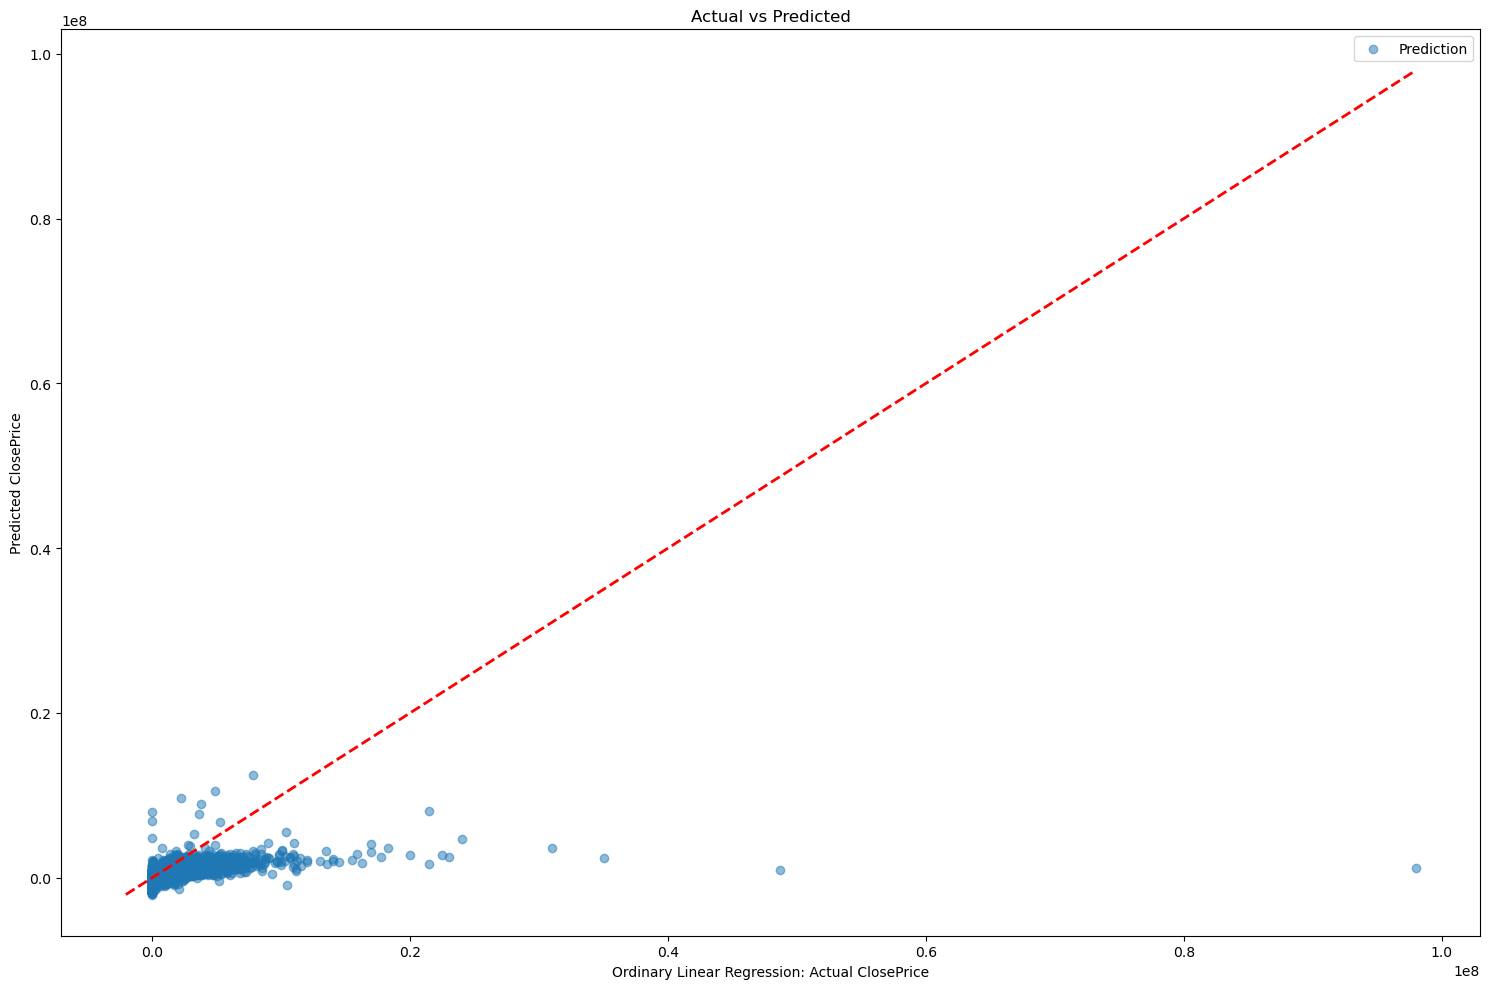

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ordinary Linear Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [12]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Ordinary Linear Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 71.16%
MAPE : 63.2639
R²   : 0.0776
MAE  : 731537.4859
MSE  : 1906662394060.6653
RMSE : 1380819.4647


## 3.2 Ridge Regression

In [13]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

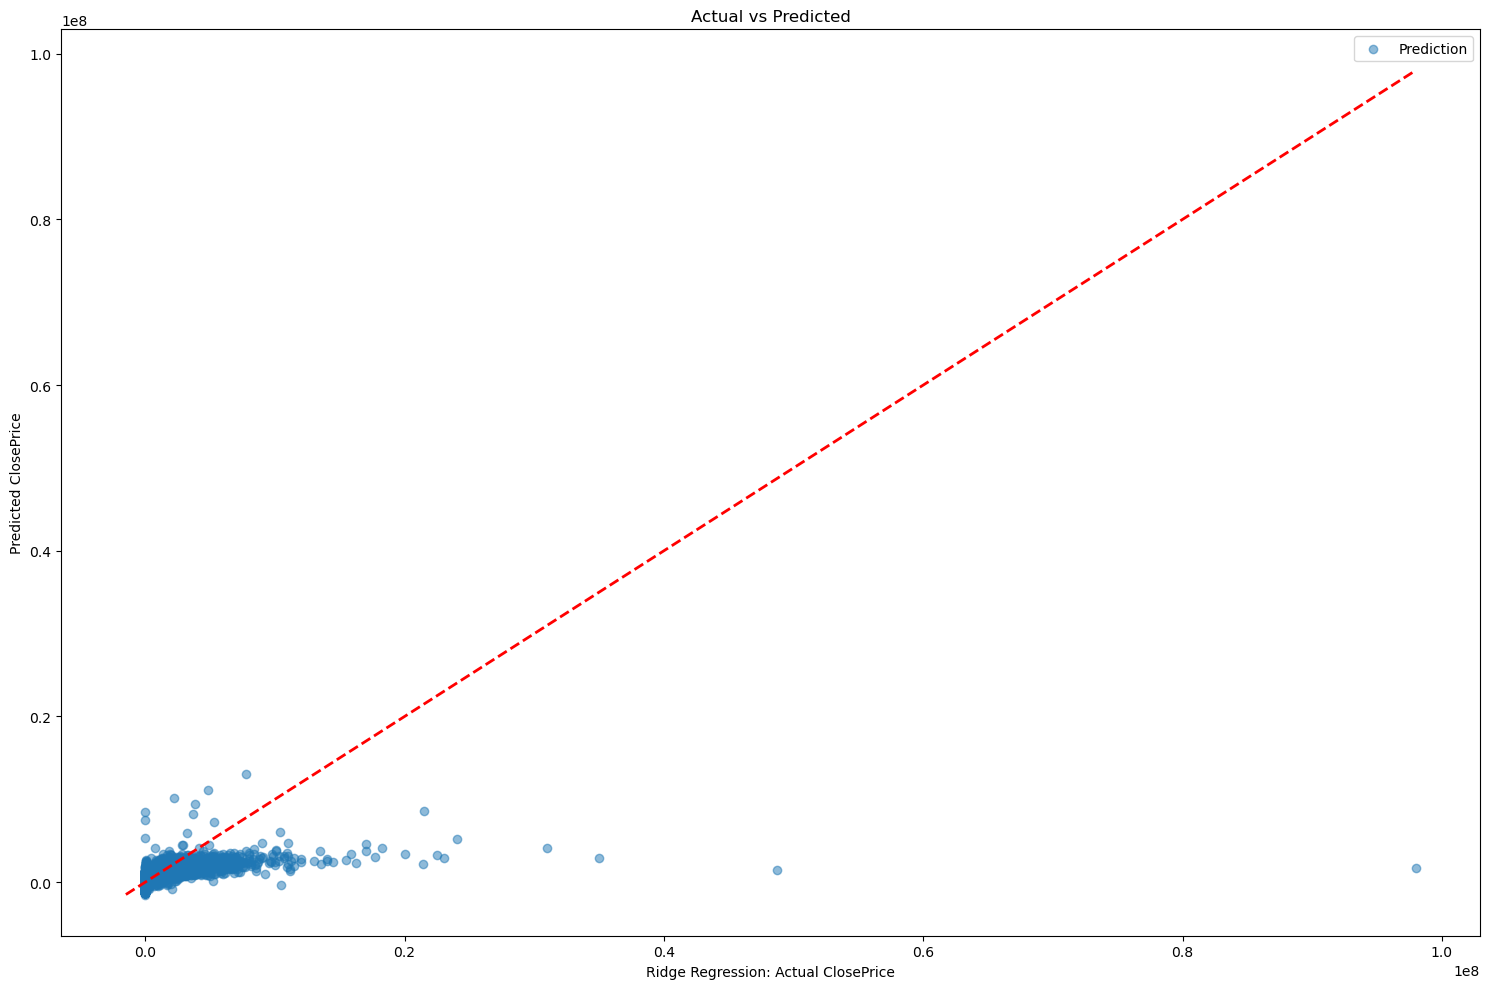

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ridge Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [15]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Ridge Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 47.23%
MAPE : 33.6863
R²   : 0.2850
MAE  : 482676.8067
MSE  : 1477916123840.2944
RMSE : 1215695.7365


## 3.3 Lasso Regression

In [16]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

D:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.552e+18, tolerance: 3.172e+14
  model = cd_fast.enet_coordinate_descent(


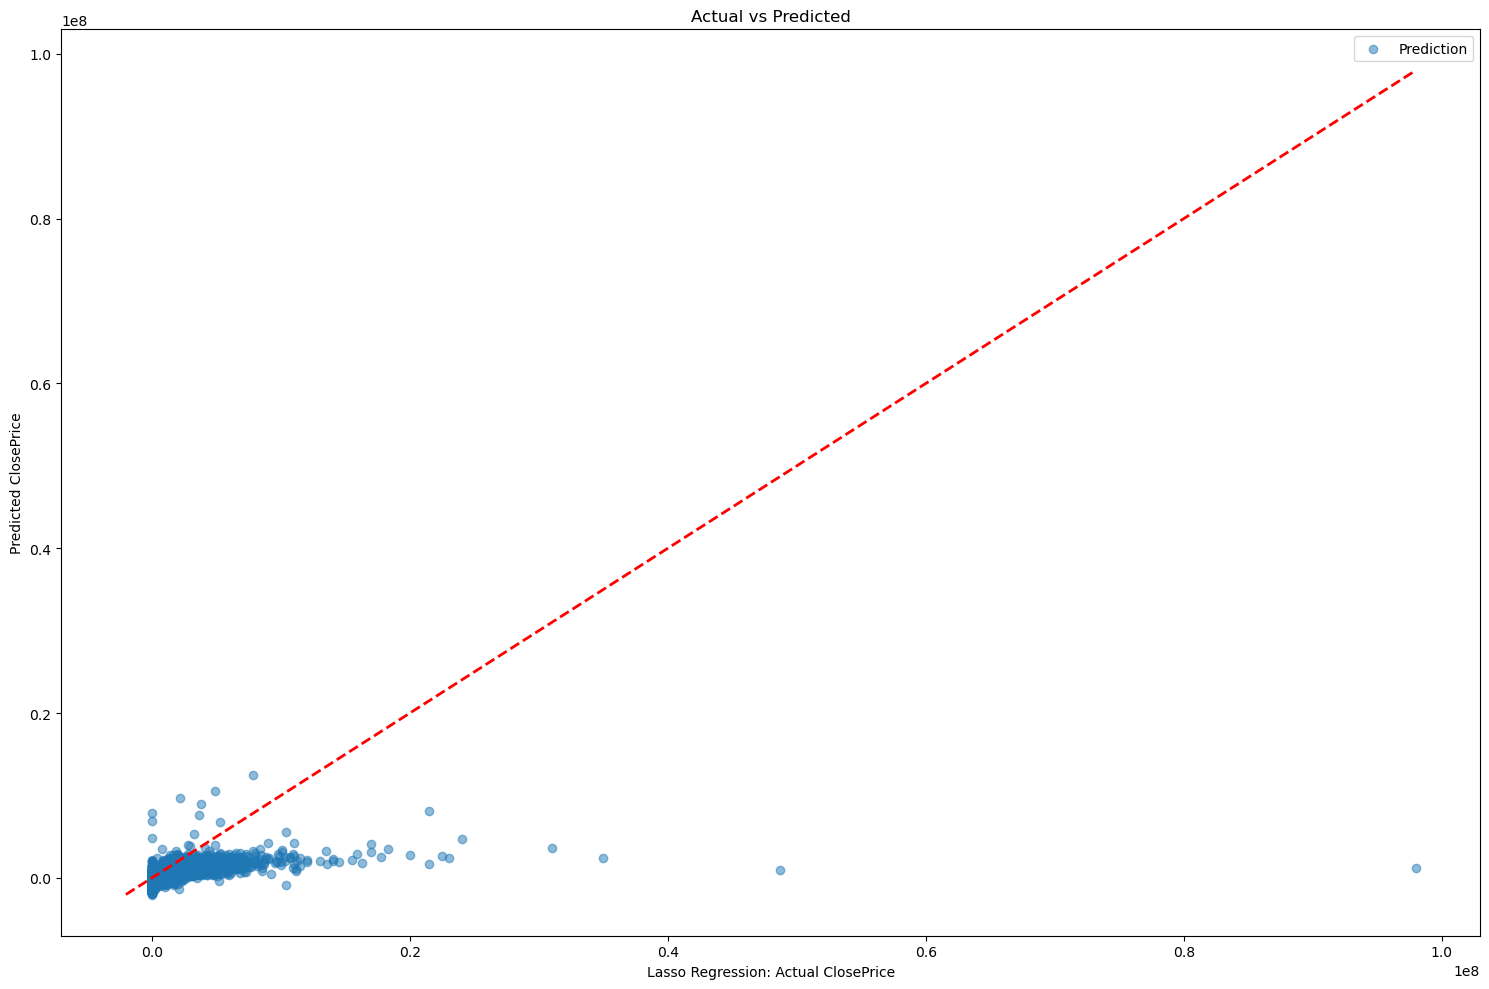

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Lasso Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [18]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Lasso Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 71.12%
MAPE : 63.2188
R²   : 0.0779
MAE  : 731150.9089
MSE  : 1905959525098.2327
RMSE : 1380564.9297


## 3.4 ElasticNet

In [19]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

D:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.556e+18, tolerance: 3.172e+14
  model = cd_fast.enet_coordinate_descent(


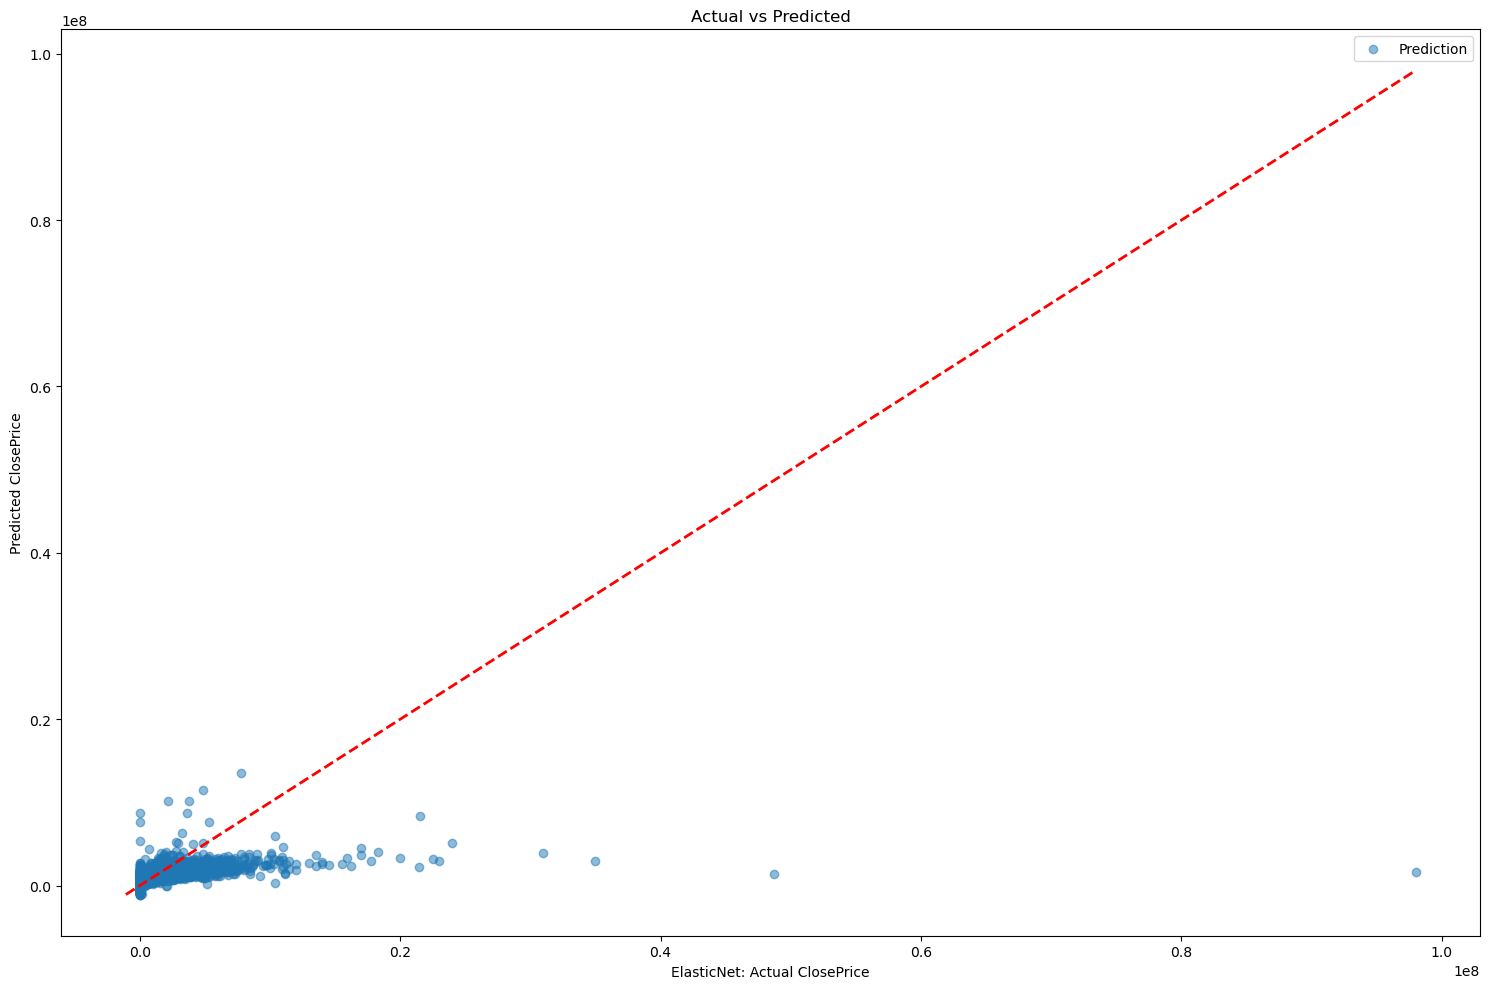

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("ElasticNet: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [21]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"ElasticNet",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 56.64%
MAPE : 23.4053
R²   : 0.2839
MAE  : 491162.4030
MSE  : 1480166663443.6089
RMSE : 1216621.0024


# 5. Rolling-Origin Backtesting

In [22]:
result_roll=[]

for X in range(4,12):
    months = sorted(data_clean["date_ym"].unique())
    data_train=data_clean[data_clean['date_ym'].isin(months[:X])]
    data_test=data_clean[data_clean['date_ym']==months[X]]
    cols=["CountyOrParish","City","StateOrProvince"]
    for col in cols:
       top10 = data_train[col].value_counts().nlargest(10).index
       data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
       data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # keep the cols consistently
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

    # linear regression
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print(f"------------------------------{X}----------------------------------")
    print("--------------Ordinary Linear regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Ordinary Linear Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Ridge regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Ridge Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = Lasso(alpha=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Lasso regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Lasso Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------ElasticNet regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"ElasticNet",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    

C:\Users\23035\AppData\Local\Temp\ipykernel_53316\1494619583.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53316\1494619583.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53316\1494619583.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

------------------------------4----------------------------------
--------------Ordinary Linear regression-------------
MdAPE: 242.30%
MAPE : 78.7245
R²   : -0.0017
MAE  : 1746401.8690
MSE  : 258846137550930.8438
RMSE : 16088695.9556
--------------Ridge regression-------------
MdAPE: 72.06%
MAPE : 26.7979
R²   : 0.0022
MAE  : 841319.8380
MSE  : 257834083296220.8438
RMSE : 16057212.8122


D:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.063e+17, tolerance: 1.712e+14
  model = cd_fast.enet_coordinate_descent(


--------------Lasso regression-------------
MdAPE: 238.70%
MAPE : 77.0823
R²   : -0.0015
MAE  : 1724316.4446
MSE  : 258796049081374.4375
RMSE : 16087139.2448


D:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.296e+17, tolerance: 1.712e+14
  model = cd_fast.enet_coordinate_descent(
C:\Users\23035\AppData\Local\Temp\ipykernel_53316\1494619583.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53316\1494619583.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

...

D:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.745e+18, tolerance: 9.598e+14
  model = cd_fast.enet_coordinate_descent(
C:\Users\23035\AppData\Local\Temp\ipykernel_53316\1494619583.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53316\1494619583.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

--------------ElasticNet regression-------------
MdAPE: 60.87%
MAPE : 22.4774
R²   : 0.3590
MAE  : 485870.1839
MSE  : 1092409362171.7411
RMSE : 1045183.8892
------------------------------11----------------------------------
--------------Ordinary Linear regression-------------
MdAPE: 57.00%
MAPE : 27.1972
R²   : 0.0151
MAE  : 576105.6159
MSE  : 54878305598825.0234
RMSE : 7407989.3088
--------------Ridge regression-------------
MdAPE: 56.96%
MAPE : 27.2412
R²   : 0.0151
MAE  : 575797.7566
MSE  : 54878729233679.9766
RMSE : 7408017.9018


D:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.747e+18, tolerance: 9.630e+14
  model = cd_fast.enet_coordinate_descent(


--------------Lasso regression-------------
MdAPE: 56.94%
MAPE : 27.2179
R²   : 0.0151
MAE  : 575811.3101
MSE  : 54878887166144.6406
RMSE : 7408028.5614
--------------ElasticNet regression-------------
MdAPE: 57.25%
MAPE : 22.3468
R²   : 0.0143
MAE  : 566072.0813
MSE  : 54924893306766.9922
RMSE : 7411133.0650


D:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.756e+18, tolerance: 9.630e+14
  model = cd_fast.enet_coordinate_descent(


# 6. Record results

In [23]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.to_csv("prediction_result.csv", index=True)
pd.DataFrame(results).to_csv("model_result.csv",index=True)
pd.DataFrame(result_roll).to_csv("model_result_roll.csv",index=True)